# 03 — Customer Segmentation (RFM + K-Means) & CLV
Rule-based **RFM segments** for interpretability, validated against unsupervised **K-Means clusters**, plus a CLV proxy per segment.

In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import warnings; warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.figsize": (11, 4.5), "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})
PINK, DARK, GREY = "#e75480", "#2d2d2d", "#999999"
RAW, PROC = "../data/raw/", "../data/processed/"
orders = pd.read_csv(PROC + "orders_clean.csv", parse_dates=["created_at", "order_date", "order_month"])
valid = orders[(~orders.cancelled) & (orders.total > 500)].copy()
daily = pd.read_csv(RAW + "daily_sales.csv", parse_dates=["day"])
fmt_pkr = mtick.FuncFormatter(lambda x, _: f"{x/1000:,.0f}K")

In [2]:
rfm = pd.read_csv(PROC + "customers_rfm.csv", parse_dates=["first_purchase","last_purchase"])
rfm.describe()[["recency_days","frequency","monetary"]].round(1)

,recency_days,frequency,monetary
count,531.0,531.0,531.0
mean,38.9,1.1,4767.6
min,1.0,1.0,1450.0
25%,16.0,1.0,3145.0
50%,29.0,1.0,3650.0
75%,57.0,1.0,5634.1
max,119.0,4.0,23099.0
std,30.1,0.4,2783.7


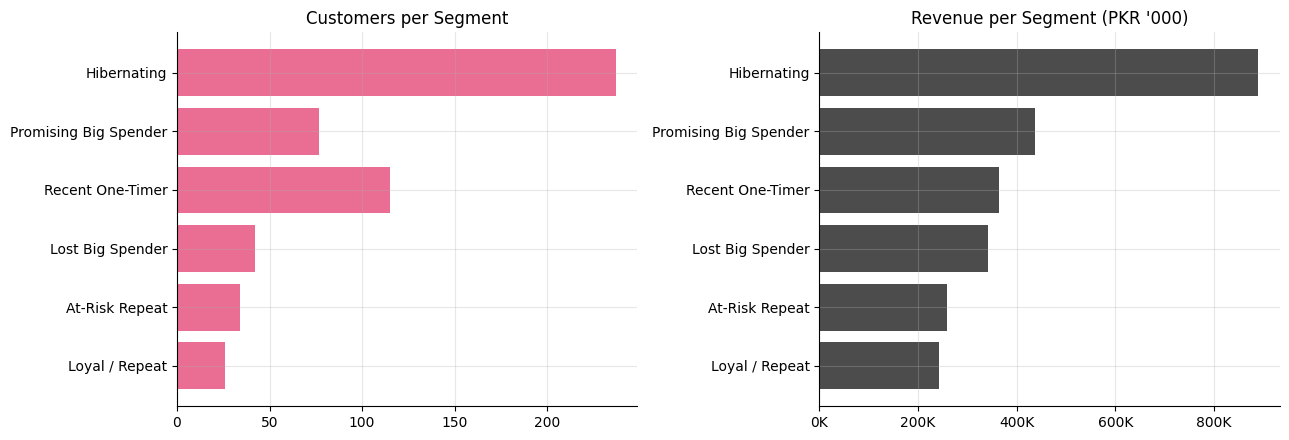

,customers,revenue,avg_monetary,avg_recency
segment,,,,
Hibernating,237,889301.0,3752.0,58.0
Promising Big Spender,77,436378.0,5667.0,14.0
Recent One-Timer,115,363397.0,3160.0,13.0
Lost Big Spender,42,341876.0,8140.0,61.0
At-Risk Repeat,34,259047.0,7619.0,48.0
Loyal / Repeat,26,241598.0,9292.0,10.0


In [3]:
seg = rfm.groupby("segment").agg(customers=("customer","count"), revenue=("monetary","sum"),
      avg_monetary=("monetary","mean"), avg_recency=("recency_days","mean")).sort_values("revenue", ascending=False)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].barh(seg.index[::-1], seg.customers[::-1], color=PINK, alpha=.85); axes[0].set_title("Customers per Segment")
axes[1].barh(seg.index[::-1], seg.revenue[::-1], color=DARK, alpha=.85)
axes[1].xaxis.set_major_formatter(fmt_pkr); axes[1].set_title("Revenue per Segment (PKR '000)")
plt.tight_layout(); plt.show(); seg.round(0)

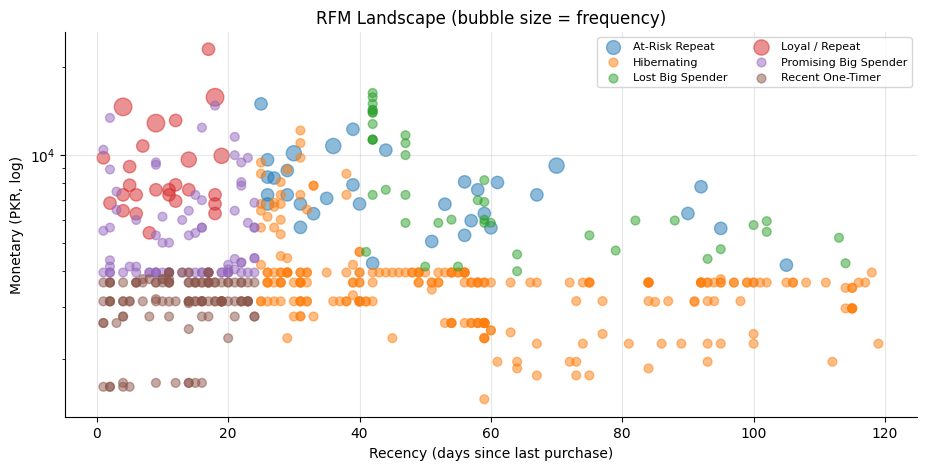

In [4]:
# RFM scatter: recency vs monetary, sized by frequency
fig, ax = plt.subplots(figsize=(11,5))
for s, g in rfm.groupby("segment"):
    ax.scatter(g.recency_days, g.monetary, s=g.frequency*40, alpha=.5, label=s)
ax.set_yscale("log"); ax.set_xlabel("Recency (days since last purchase)"); ax.set_ylabel("Monetary (PKR, log)")
ax.legend(ncol=2, fontsize=8); ax.set_title("RFM Landscape (bubble size = frequency)"); plt.show()

In [5]:
# K-Means validation: silhouette by k + cluster/segment crosstab
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
X = rfm[["recency_days","frequency","monetary"]].copy()
X["monetary"], X["frequency"] = np.log1p(X.monetary), np.log1p(X.frequency)
Xs = StandardScaler().fit_transform(X)
for k in range(2, 7):
    print(f"k={k}: silhouette={silhouette_score(Xs, KMeans(k, n_init=10, random_state=42).fit_predict(Xs)):.3f}")
pd.crosstab(rfm.segment, rfm.kmeans_cluster)

k=2: silhouette=0.561
k=3: silhouette=0.456


k=4: silhouette=0.496
k=5: silhouette=0.459


k=6: silhouette=0.466


kmeans_cluster,0,1,2,3
segment,,,,
At-Risk Repeat,0,0,34,0
Hibernating,85,128,0,24
Lost Big Spender,2,14,0,26
Loyal / Repeat,0,0,26,0
Promising Big Spender,49,0,0,28
Recent One-Timer,115,0,0,0


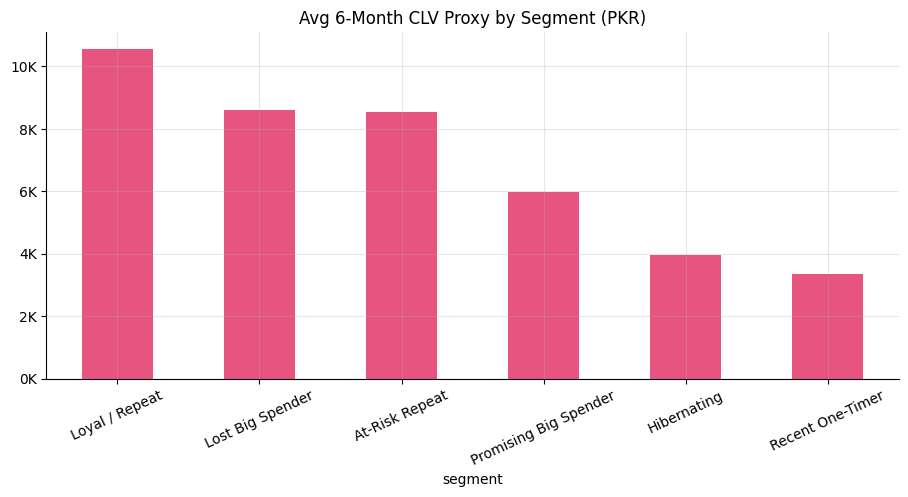

,customer,frequency,monetary,recency_days,segment,main_city
215,CUST-0225,2,23099.00,17,Loyal / Repeat,Lahore
211,CUST-0221,1,16348.00,42,Lost Big Spender,Lahore
230,CUST-0240,4,15800.00,18,Loyal / Repeat,Lahore
210,CUST-0220,1,15795.00,42,Lost Big Spender,Islamabad
214,CUST-0224,1,14994.00,42,Lost Big Spender,Karachi
297,CUST-0309,2,14994.00,25,At-Risk Repeat,Lahore
386,CUST-0401,1,14793.00,18,Promising Big Spender,Karachi
314,CUST-0327,4,14639.12,4,Loyal / Repeat,Multan
217,CUST-0227,1,14294.00,42,Lost Big Spender,Rawalpindi
212,CUST-0222,1,14285.00,42,Lost Big Spender,Lahore


In [6]:
# CLV proxy by segment + top 10 customers
clv = rfm.groupby("segment").clv_6m_proxy.mean().sort_values(ascending=False)
ax = clv.plot.bar(color=PINK, title="Avg 6-Month CLV Proxy by Segment (PKR)", rot=25)
ax.yaxis.set_major_formatter(fmt_pkr); plt.show()
rfm.nlargest(10, "monetary")[["customer","frequency","monetary","recency_days","segment","main_city"]]

### Findings
- **~11% of customers are repeat buyers** but contribute disproportionate revenue; `Loyal / Repeat` + `Promising Big Spender` (~19% of base) drive ~40%+ of revenue.
- 237 customers (45%) are **Hibernating** — acquired during the May–June push and never returned. A win-back flow (WhatsApp/SMS + discount code) is the cheapest revenue lever available.
- K-Means (best silhouette at k=4) broadly reproduces the rule-based segments — the segmentation is robust, not an artifact of arbitrary thresholds.
- Top 10 customers alone = ~PKR 190K+. At this scale, a manual VIP outreach list is feasible and high-ROI.